In [1]:
import pandas as pd
import numpy as np
import torch

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
from torch import Size

import shap
import umap
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double
torch.manual_seed(123)

# Configuration

In [2]:
X_COLS = ["polymer conc", "dose", "paav", "pdgh", "helper"]
Y_COL = "viral_titre"
BATCH_SIZE = 5          # experiments suggested per round
SEED = 123        

X_MIN = torch.tensor([0.024, 1.5, 0.27, 1.00, 1.0], dtype=dtype, device=device)
X_MAX = torch.tensor([0.096, 4.0, 1.00, 1.44, 3.0], dtype=dtype, device=device)

# Bounds in scaled [0,1] space
BOUNDS = torch.stack([
    torch.zeros(len(X_COLS), dtype=dtype, device=device),
    torch.ones(len(X_COLS),  dtype=dtype, device=device),
])

# Feature names
SHAP_FEATURE_NAMES = ["Polymer", "Dose", "pAAV", "pDGH", "pHGTI"]

# Helper functions

In [ ]:
def prepare_tensors(df):
    # Convert a dataframe to scaled train_x and log10-transformed train_y tensors
    X_raw = torch.tensor(df[X_COLS].values, dtype=dtype, device=device)
    y_raw = torch.tensor(df[Y_COL].values,  dtype=dtype, device=device).unsqueeze(-1)
    train_x = (X_raw - X_MIN) / (X_MAX - X_MIN)
    train_y = torch.log10(y_raw)
    return train_x, train_y


def fit_gp_model(train_x, train_y):
    # Fit a SingleTaskGP on scaled inputs and log10-transformed outputs
    model = SingleTaskGP(train_x, train_y)
    mll   = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


def make_qei(model, train_y, sampler):
    # Build a q-EI acquisition function from the current model and data
    best_f = train_y.max()
    return qExpectedImprovement(model=model, best_f=best_f, sampler=sampler)


def run_bo_round(train_x, train_y, round_num, batch_size=BATCH_SIZE, seed=SEED):
    """
    Run one round of Bayesian optimisation.

    Parameters
    ----------
    train_x   : scaled input tensor
    train_y   : log10-transformed output tensor
    round_num : int, used for CSV filename and display
    batch_size: number of experiments to suggest
    seed      : random seed for reproducibility

    Returns
    -------
    suggested_df : DataFrame with suggested experiments in real-world units
                   plus GP mean prediction (log10 titre) and std uncertainty
                   for each candidate
    model        : the fitted GP model
    """
    sampler = SobolQMCNormalSampler(sample_shape=Size([128]))
    torch.manual_seed(seed)

    model    = fit_gp_model(train_x, train_y)
    acq_func = make_qei(model, train_y, sampler)

    candidates_scaled, _ = optimize_acqf(
        acq_function=acq_func,
        bounds=BOUNDS,
        q=batch_size,
        num_restarts=10,
        raw_samples=256,
    )

    # Convert back to real-world units
    candidates_real = X_MIN + candidates_scaled * (X_MAX - X_MIN)

    suggested_df = pd.DataFrame(
        candidates_real.cpu().numpy(),
        columns=X_COLS,
    ).round(3)

    # Uncertainty
    model.eval()
    with torch.no_grad():
        posterior = model.posterior(candidates_scaled)
        means_log10 = posterior.mean.squeeze(-1).cpu().numpy()          # log10 titre
        stds_log10  = posterior.variance.sqrt().squeeze(-1).cpu().numpy()

    suggested_df["gp_mean_log10_titre"] = np.round(means_log10, 4)
    suggested_df["gp_std_log10_titre"]  = np.round(stds_log10,  4)

    fname = f"suggested_experiments_round{round_num}.csv"
    suggested_df.to_csv(fname, index=False)
    print(f"Round {round_num} suggestions saved to {fname}")
    print(suggested_df.to_string(index=False))

    return suggested_df, model

# Load seed data

In [4]:
seed_data = pd.read_excel("seed_dataset.xlsx")
seed_data

,polymer conc,np,dose,paav,pdgh,helper,viral_titre
0,0.048,10,4.00,1.000,1.44,3,5.350000e+08
1,0.048,10,1.50,0.270,1.00,1,2.915000e+08
2,0.072,15,1.50,0.270,1.22,3,2.772500e+08
3,0.024,5,4.00,1.000,1.22,1,3.797500e+08
4,0.072,15,4.00,0.270,1.44,1,4.017500e+08
5,0.024,5,1.50,1.000,1.00,3,2.878235e+08
6,0.048,10,2.75,0.635,1.22,2,3.007500e+08
7,0.072,15,2.75,1.000,1.44,1,2.994586e+09
8,0.024,5,2.75,0.270,1.00,3,8.180000e+08
9,0.072,15,4.00,0.270,1.00,2,7.495000e+08


In [5]:
master_results = seed_data.copy()
master_results["round"] = 0
master_results

,polymer conc,np,dose,paav,pdgh,helper,viral_titre,round
0,0.048,10,4.00,1.000,1.44,3,5.350000e+08,0
1,0.048,10,1.50,0.270,1.00,1,2.915000e+08,0
2,0.072,15,1.50,0.270,1.22,3,2.772500e+08,0
3,0.024,5,4.00,1.000,1.22,1,3.797500e+08,0
4,0.072,15,4.00,0.270,1.44,1,4.017500e+08,0
5,0.024,5,1.50,1.000,1.00,3,2.878235e+08,0
6,0.048,10,2.75,0.635,1.22,2,3.007500e+08,0
7,0.072,15,2.75,1.000,1.44,1,2.994586e+09,0
8,0.024,5,2.75,0.270,1.00,3,8.180000e+08,0
9,0.072,15,4.00,0.270,1.00,2,7.495000e+08,0


# Suggest Round 1 experiments

In [6]:
train_x, train_y = prepare_tensors(master_results)
suggested_for_round1, model = run_bo_round(train_x, train_y, round_num=1)

c:\Users\ASUS\anaconda3\Lib\site-packages\botorch\acquisition\monte_carlo.py:393: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Round 1 suggestions saved to suggested_experiments_round1.csv
 polymer conc  dose  paav  pdgh  helper  gp_mean_log10_titre  gp_std_log10_titre
        0.096 2.538 1.000 1.440   1.000               9.3080              0.1387
        0.096 2.941 1.000 1.440   1.000               9.3142              0.1340
        0.035 2.548 1.000 1.440   1.000               9.2933              0.1493
        0.027 1.786 0.682 1.121   2.088               8.5070              0.1871
        0.040 2.876 1.000 1.440   1.000               9.3160              0.1303


# Round 1 results

In [7]:
round1_results = pd.read_excel("round1_results.xlsx")
round1_results["round"] = 1
master_results = pd.concat([master_results, round1_results], ignore_index=True)
round1_results

,polymer conc,dose,paav,pdgh,helper,viral_titre,round
0,0.027,1.786,0.682,1.121,2.088,2.265496e+09,1
1,0.035,2.548,1.000,1.440,1.000,2.915289e+09,1
2,0.040,2.877,1.000,1.440,1.000,2.419474e+09,1
3,0.096,2.541,1.000,1.440,1.000,3.597637e+09,1
4,0.096,2.941,1.000,1.440,1.000,1.657103e+09,1


# Suggest Round 2 experiments

In [8]:
train_x, train_y = prepare_tensors(seed_data)
suggested_for_round2, model = run_bo_round(train_x, train_y, round_num=2)

c:\Users\ASUS\anaconda3\Lib\site-packages\botorch\acquisition\monte_carlo.py:393: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Round 2 suggestions saved to suggested_experiments_round2.csv
 polymer conc  dose  paav  pdgh  helper  gp_mean_log10_titre  gp_std_log10_titre
        0.096 2.554 1.000 1.440   1.000               9.3148              0.1353
        0.050 2.599 1.000 1.440   2.987               9.2804              0.1523
        0.096 1.500 0.508 1.438   1.000               8.7097              0.1388
        0.096 2.939 1.000 1.440   1.000               9.3154              0.1334
        0.028 2.881 1.000 1.440   1.000               9.2807              0.1488


# Round 2 results

In [9]:
round2_results = pd.read_excel("round2_results.xlsx")
round2_results["round"] = 2
master_results = pd.concat([master_results, round2_results], ignore_index=True)
round2_results

,polymer conc,dose,paav,pdgh,helper,viral_titre,round
0,0.096,2.5539,1.000,1.440,1.000,1.388670e+09,2
1,0.050,2.5998,1.000,1.440,2.987,8.247758e+08,2
2,0.096,1.5000,0.508,1.438,1.000,9.944164e+08,2
3,0.096,2.9400,1.000,1.440,1.000,2.047578e+09,2
4,0.028,2.8812,1.000,1.440,1.000,1.738847e+09,2


# Suggest Round 3 experiments

In [10]:
train_x, train_y = prepare_tensors(master_results)
suggested_for_round3, model = run_bo_round(train_x, train_y, round_num=3)

c:\Users\ASUS\anaconda3\Lib\site-packages\botorch\acquisition\monte_carlo.py:393: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Round 3 suggestions saved to suggested_experiments_round3.csv
 polymer conc  dose  paav  pdgh  helper  gp_mean_log10_titre  gp_std_log10_titre
        0.024 2.466 0.903 1.142   1.252               9.1152              0.2613
        0.035 2.510 0.403 1.108   1.159               9.1340              0.2617
        0.058 2.506 1.000 1.402   1.000               9.1818              0.2558
        0.024 1.500 0.270 1.097   1.000               9.1322              0.2517
        0.096 2.236 0.858 1.093   3.000               9.1173              0.2677


# Round 3 results

In [11]:
round3_results = pd.read_excel("round3_results.xlsx")
round3_results["round"] = 3
master_results = pd.concat([master_results, round3_results], ignore_index=True)
round3_results

,polymer conc,dose,paav,pdgh,helper,viral_titre,round
0,0.024,2.4660,0.903,1.142,1.252,8.932500e+08,3
1,0.035,2.5116,0.403,1.108,1.159,7.625000e+08,3
2,0.058,2.5074,1.000,1.402,1.000,1.184750e+09,3
3,0.024,1.5000,0.270,1.097,1.000,6.358547e+08,3
4,0.096,2.2360,0.858,1.093,3.000,1.882500e+09,3


# Suggest Round 4 experiments

In [12]:
train_x, train_y = prepare_tensors(master_results)
suggested_for_round4, model = run_bo_round(train_x, train_y, round_num=4)

master_results.to_csv("master_results.csv", index=False)
print("master_results.csv saved.")

c:\Users\ASUS\anaconda3\Lib\site-packages\botorch\acquisition\monte_carlo.py:393: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Round 4 suggestions saved to suggested_experiments_round4.csv
 polymer conc  dose  paav  pdgh  helper  gp_mean_log10_titre  gp_std_log10_titre
        0.024 1.972 1.000 1.132   3.000               9.2817              0.1678
        0.050 1.992 0.886 1.419   1.086               9.1351              0.0997
        0.024 1.500 1.000 1.108   3.000               9.2734              0.1736
        0.096 4.000 1.000 1.330   1.000               8.6742              0.3190
        0.096 1.500 1.000 1.130   3.000               9.2503              0.1933
master_results.csv saved.


# SHAP – feature importance

  0%|          | 0/34 [00:00<?, ?it/s]

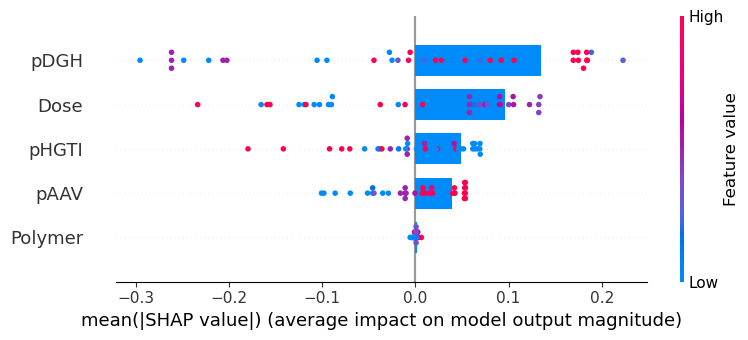

In [13]:
# SHAP on log10(viral_titre) scale
model.eval()

n_bg   = min(50, train_x.shape[0])
bg_idx = torch.randperm(train_x.shape[0], device=train_x.device)[:n_bg]
X_bg      = train_x[bg_idx].detach().cpu().numpy()
X_explain = train_x.detach().cpu().numpy()

def gp_mean_predict(X_np):
    """GP posterior mean in log10(titre) space."""
    X_t = torch.tensor(X_np, dtype=torch.double, device=device)
    with torch.no_grad():
        return model.posterior(X_t).mean.squeeze(-1).detach().cpu().numpy()

explainer   = shap.KernelExplainer(gp_mean_predict, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)

# Beeswarm
shap.summary_plot(shap_values, X_explain, feature_names=SHAP_FEATURE_NAMES,
                  show=False, plot_size=(7, 5))
plt.savefig("shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")

# Bar
shap.summary_plot(shap_values, X_explain, feature_names=SHAP_FEATURE_NAMES,
                  plot_type="bar", show=True)

  0%|          | 0/34 [00:00<?, ?it/s]

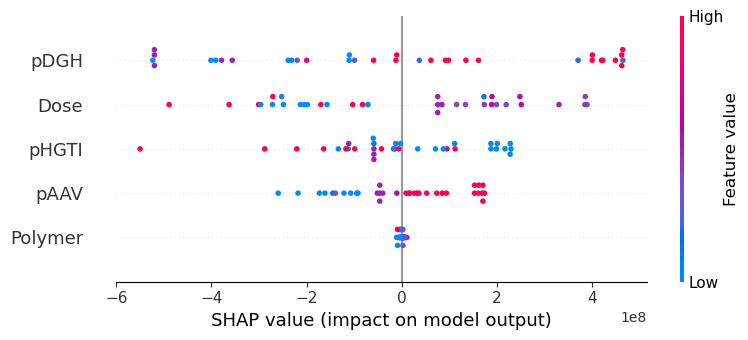

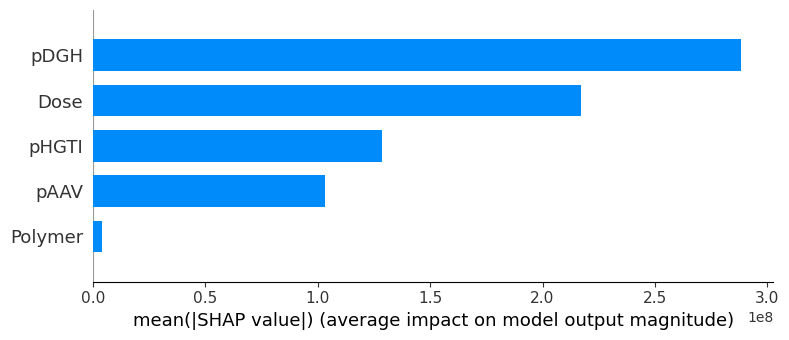

In [14]:
# SHAP on original viral titre scale (10^mean)
def gp_predict_original_units(X_np):
    """GP posterior mean back-transformed to titre units."""
    X_t = torch.tensor(X_np, dtype=torch.double, device=device)
    with torch.no_grad():
        mean_log10 = model.posterior(X_t).mean.squeeze(-1)
    return (10 ** mean_log10).detach().cpu().numpy()

explainer_orig   = shap.KernelExplainer(gp_predict_original_units, X_bg)
shap_values_orig = explainer_orig.shap_values(X_explain, nsamples=300)

shap.summary_plot(shap_values_orig, X_explain, feature_names=SHAP_FEATURE_NAMES)
shap.summary_plot(shap_values_orig, X_explain, feature_names=SHAP_FEATURE_NAMES,
                  plot_type="bar")

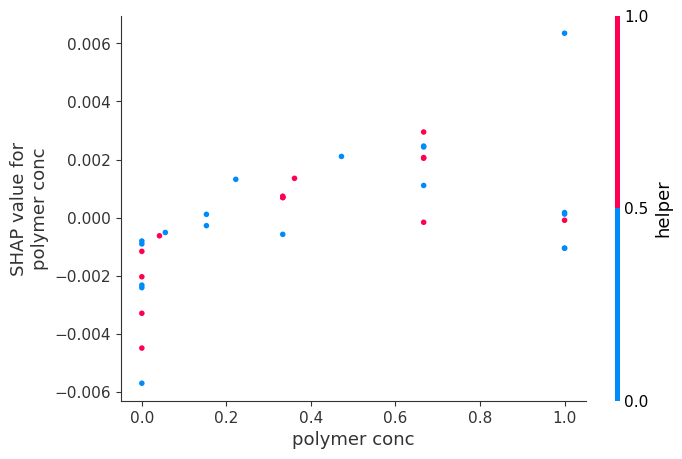

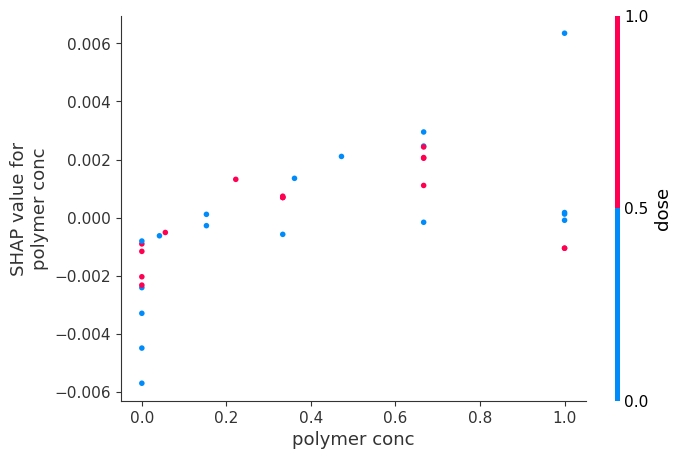

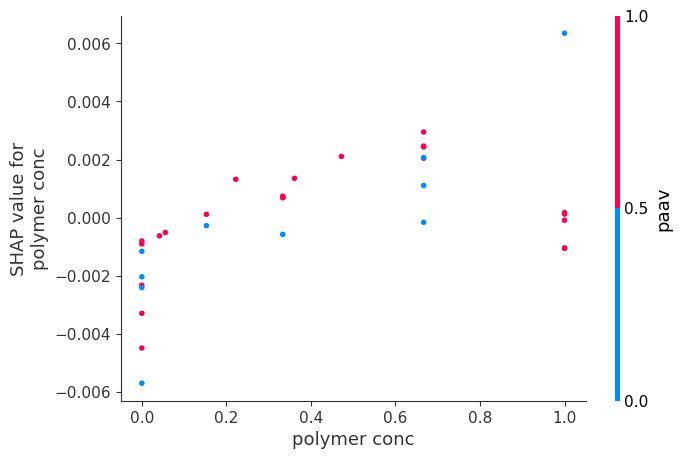

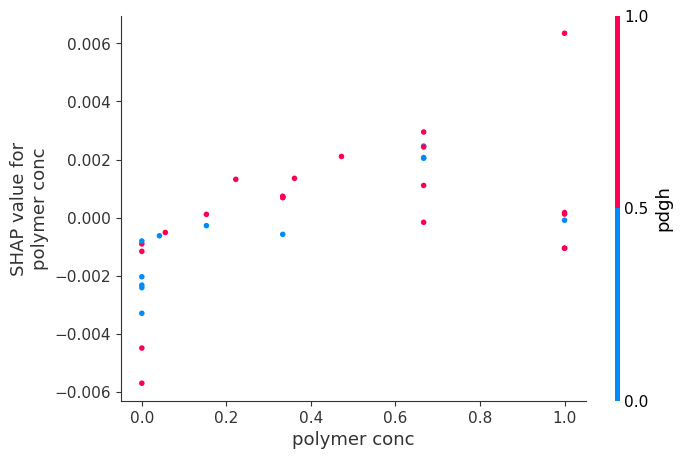

In [15]:
# Dependence plots
for interaction in ["helper", "dose", "paav", "pdgh"]:
    shap.dependence_plot(
        "polymer conc",
        shap_values,
        X_explain,
        feature_names=X_COLS,
        interaction_index=interaction,
    )

# Updating UMAP

c:\Users\ASUS\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30788\1279711293.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_rounds))


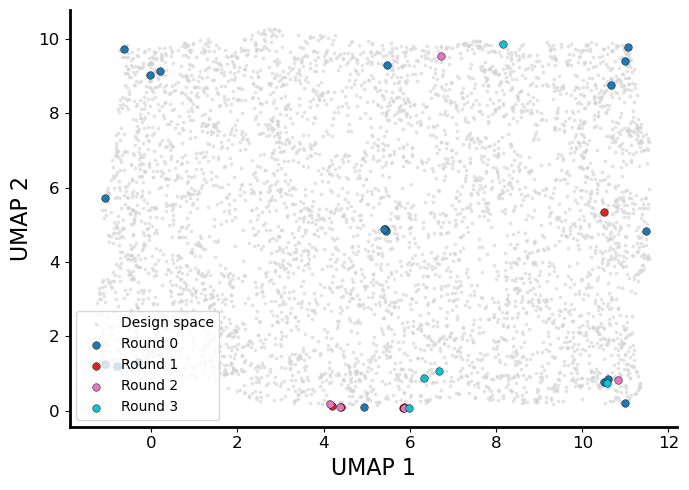

In [16]:
df_umap = pd.read_csv("master_results.csv")

n_background = 5000
dim          = X_MIN.shape[0]
uniform      = torch.rand((n_background, dim), dtype=X_MIN.dtype, device=X_MIN.device)
background   = (X_MIN + uniform * (X_MAX - X_MIN)).detach().cpu().numpy()

X_data    = df_umap[X_COLS].to_numpy(dtype=float)
valid     = ~np.isnan(X_data).any(axis=1)
X_valid   = X_data[valid]
round_labels = df_umap.loc[valid, "round"].to_numpy()

X_all     = np.vstack([background, X_valid])
reducer   = umap.UMAP(n_neighbors=30, min_dist=0.3, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_all)

bg_emb   = embedding[:n_background]
data_emb = embedding[n_background:]

plt.figure(figsize=(7, 5))
plt.scatter(bg_emb[:, 0], bg_emb[:, 1], s=3, c="lightgrey", alpha=0.5, label="Design space")

unique_rounds = np.unique(round_labels)
cmap = plt.cm.get_cmap("tab10", len(unique_rounds))
for i, r in enumerate(unique_rounds):
    mask = round_labels == r
    plt.scatter(data_emb[mask, 0], data_emb[mask, 1],
                s=30, color=cmap(i), edgecolors="k", linewidths=0.3,
                label=f"Round {int(r)}")

ax = plt.gca()
plt.xlabel("UMAP 1", size=16)
plt.ylabel("UMAP 2", size=16)
plt.legend(loc="best", fontsize="medium")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_linewidth(2)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.savefig("umap_design_space.png", dpi=300, bbox_inches="tight")
plt.show()

# Results – viral titre by round

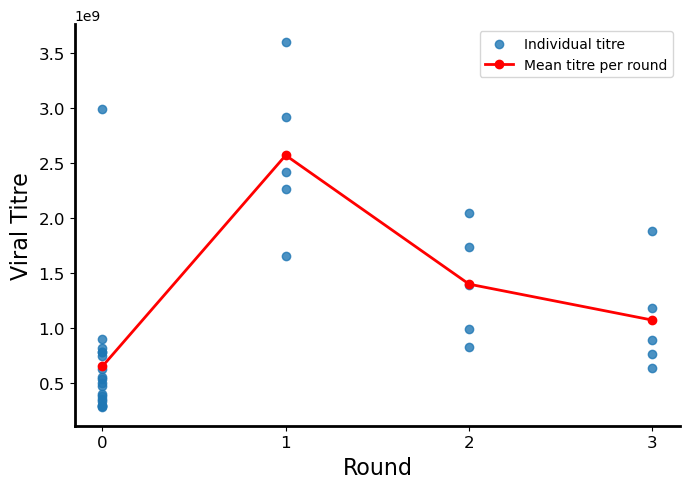

In [17]:
df_results = pd.read_csv("master_results.csv")
df_results.columns = [c.strip().replace(" ", "_") for c in df_results.columns]
df_results["round"]       = pd.to_numeric(df_results["round"], errors="coerce").astype("Int64")
df_results["viral_titre"] = pd.to_numeric(df_results["viral_titre"], errors="coerce")
df_results = df_results.dropna(subset=["round", "viral_titre"]).copy()
df_results["round"] = df_results["round"].astype(int)

mean_by_round = df_results.groupby("round", as_index=False)["viral_titre"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_results["round"], df_results["viral_titre"], alpha=0.8, label="Individual titre")
ax.plot(mean_by_round["round"], mean_by_round["viral_titre"],
        marker="o", linewidth=2, color="red", label="Mean titre per round")

ax.set_xlabel("Round", size=16)
ax.set_ylabel("Viral Titre", size=16)
ax.set_xticks(sorted(df_results["round"].unique()))
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_linewidth(2)
ax.legend()
plt.tight_layout()
plt.savefig("viral_titre_by_round.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot uncertainty

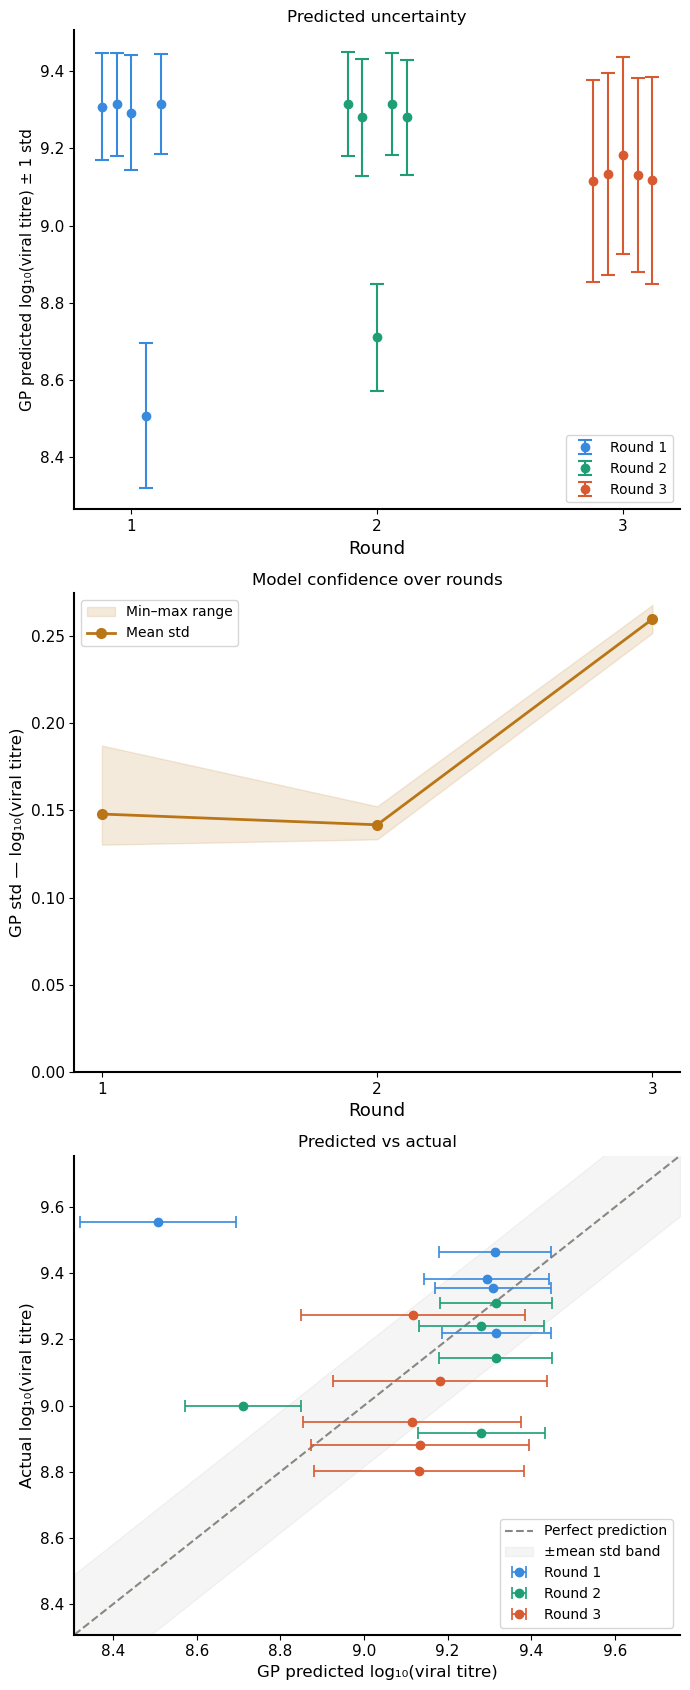

In [22]:
rounds_to_plot = [
    (1, suggested_for_round1, round1_results),
    (2, suggested_for_round2, round2_results),
    (3, suggested_for_round3, round3_results),
]

colors = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, axes = plt.subplots(3, 1, figsize=(7, 17))

# Plot 1: predicted mean ± 1 std per candidate per round
ax1 = axes[0]
jitter = np.linspace(-0.12, 0.12, 5)

for idx, (rnum, sdf, _) in enumerate(rounds_to_plot):
    means = sdf['gp_mean_log10_titre'].values
    stds  = sdf['gp_std_log10_titre'].values
    xs    = np.full(len(means), rnum) + jitter[:len(means)]
    ax1.errorbar(
        xs, means, yerr=stds,
        fmt='o', color=colors[idx],
        ecolor=colors[idx], elinewidth=1.5, capsize=5, capthick=1.5,
        markersize=6, label=f'Round {rnum}',
    )

ax1.set_xlabel('Round', fontsize=13)
ax1.set_ylabel('GP predicted log₁₀(viral titre) ± 1 std', fontsize=11)
ax1.set_xticks([r for r, _, _ in rounds_to_plot])
ax1.tick_params(labelsize=11)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['bottom', 'left']].set_linewidth(1.5)
ax1.legend(fontsize=10)
ax1.set_title('Predicted uncertainty', fontsize=12)

# Plot 2: average uncertainty per round
ax2 = axes[1]
rnums     = [r for r, _, _ in rounds_to_plot]
mean_stds = [sdf['gp_std_log10_titre'].mean() for _, sdf, _ in rounds_to_plot]
min_stds  = [sdf['gp_std_log10_titre'].min()  for _, sdf, _ in rounds_to_plot]
max_stds  = [sdf['gp_std_log10_titre'].max()  for _, sdf, _ in rounds_to_plot]

ax2.fill_between(rnums, min_stds, max_stds, color='#BA7517', alpha=0.15, label='Min–max range')
ax2.plot(rnums, mean_stds, 'o-', color='#BA7517', linewidth=2, markersize=7, label='Mean std')

ax2.set_xlabel('Round', fontsize=13)
ax2.set_ylabel('GP std — log₁₀(viral titre)', fontsize=12)
ax2.set_xticks(rnums)
ax2.set_ylim(bottom=0)
ax2.tick_params(labelsize=11)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['bottom', 'left']].set_linewidth(1.5)
ax2.legend(fontsize=10)
ax2.set_title('Model confidence over rounds', fontsize=12)

# Plot 3: predicted vs actual per round
ax3 = axes[2]

all_predicted = []
all_actual    = []

for idx, (rnum, sdf, rdf) in enumerate(rounds_to_plot):
    predicted = sdf['gp_mean_log10_titre'].values
    stds      = sdf['gp_std_log10_titre'].values
    actual    = np.log10(rdf['viral_titre'].values)

    ax3.errorbar(
        predicted, actual, xerr=stds,
        fmt='o', color=colors[idx],
        ecolor=colors[idx], elinewidth=1.2, capsize=4, capthick=1.2,
        markersize=6, label=f'Round {rnum}', zorder=3,
    )
    all_predicted.extend(predicted)
    all_actual.extend(actual)

# Perfect prediction line
all_vals = all_predicted + all_actual
lo, hi   = min(all_vals) - 0.2, max(all_vals) + 0.2
ax3.plot([lo, hi], [lo, hi], '--', color='#888780', linewidth=1.5,
         label='Perfect prediction', zorder=2)

# Shade ±1 std band around perfect line (using mean std as a guide)
mean_std_all = np.mean([sdf['gp_std_log10_titre'].mean() for _, sdf, _ in rounds_to_plot])
ax3.fill_between([lo, hi], [lo - mean_std_all, hi - mean_std_all],
                            [lo + mean_std_all, hi + mean_std_all],
                 color='#888780', alpha=0.08, zorder=1, label='±mean std band')

ax3.set_xlabel('GP predicted log₁₀(viral titre)', fontsize=12)
ax3.set_ylabel('Actual log₁₀(viral titre)', fontsize=12)
ax3.set_xlim(lo, hi)
ax3.set_ylim(lo, hi)
ax3.tick_params(labelsize=11)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['bottom', 'left']].set_linewidth(1.5)
ax3.legend(fontsize=10)
ax3.set_title('Predicted vs actual', fontsize=12)

plt.tight_layout()
plt.savefig('bo_uncertainty_by_round.png', dpi=300, bbox_inches='tight')
plt.show()